# Hiring Bias Fairness Analysis with AIF360 and Multiple Protected Attributes

This notebook converts the hiring-bias project from separate local scripts into a single Google Colab friendly workflow with the same core analysis logic.

The notebook will:
- install the required libraries in Colab
- load the hiring dataset from `/content` or from a Colab upload
- reproduce exploratory data analysis from the project
- build AIF360 fairness datasets
- train five machine-learning models
- compare fairness and utility before and after AIF360 Reweighing
- repeat the fairness analysis for `Gender`, `Age`, `MentalHealth`, `Accessibility`, and `Country`
- save tables and figures into a notebook output folder

Expected dataset columns:
`Age`, `Accessibility`, `EdLevel`, `Employment`, `Gender`, `MentalHealth`, `MainBranch`, `YearsCode`, `YearsCodePro`, `Country`, `PreviousSalary`, `HaveWorkedWith`, `ComputerSkills`, and `Employed`.


In [ ]:
!pip -q install aif360 seaborn


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 259.7/259.7 kB 10.1 MB/s eta 0:00:00


This setup cell installs the AIF360 fairness toolkit and the plotting dependency used by the notebook. In Colab, running the install cell first makes the rest of the notebook self-contained instead of depending on the local `AIF360/` folder from the original project.


In [ ]:
import inspect
import warnings
import zipfile
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

from aif360.algorithms.preprocessing.reweighing import Reweighing
from aif360.datasets import BinaryLabelDataset
from aif360.metrics import BinaryLabelDatasetMetric, ClassificationMetric
from sklearn.base import clone
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier

try:
    from google.colab import files
    IN_COLAB = True
except ImportError:
    files = None
    IN_COLAB = False

warnings.filterwarnings("ignore", category=FutureWarning)
plt.style.use("seaborn-v0_8-whitegrid")
sns.set_palette("Set2")

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 120)
pd.set_option("display.float_format", lambda value: f"{value:0.4f}")

RANDOM_STATE = 42
COUNTRY_PRIVILEGED = "United States of America"
TOP_COUNTRIES = 12
MIN_COUNTRY_COUNT = 20
RF_N_JOBS = -1 if IN_COLAB else 1
OUTPUT_DIR = Path("/content/hiring_bias_outputs" if IN_COLAB else "hiring_bias_outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Running in Colab:", IN_COLAB)
print("Output directory:", OUTPUT_DIR.resolve())


pip install 'aif360[Reductions]'
pip install 'aif360[Reductions]'
pip install 'aif360[inFairness]'
pip install 'aif360[Reductions]'


Running in Colab: True
Output directory: /content/hiring_bias_outputs


In [ ]:
pip install 'aif360[Reductions]' 'aif360[inFairness]'

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 2.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.2/40.2 kB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 251.6/251.6 kB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.8/45.8 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.3/37.3 MB 40.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 259.7/259.7 kB 9.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 268.5/268.5 kB 17.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 55.7 MB/s eta 0:00:00
  Attempting uninstall: scipy
    Found existing installation: scipy 1.16.3
    Uninstalling scipy-1.16.3:
      Successfully uninstalled scipy-1.16.3


The above cell installs the optional dependencies for `aif360` to enable additional fairness mitigation algorithms. You might need to restart the runtime for the changes to take full effect, though often reloading the modules is enough.

This cell imports the same modeling and fairness libraries used in the original scripts. It also sets notebook-wide defaults, creates an output directory, and switches the Random Forest parallelism setting so the notebook stays portable outside Colab as well.


## 1. Load the Hiring Dataset


In [ ]:
from google.colab import files
from pathlib import Path

uploaded = files.upload()  # select hiring_bias_dataset.csv
dataset_path = Path(f"/content/{next(iter(uploaded))}")

print("Using dataset:", dataset_path)



Saving hiring_bias_dataset.csv to hiring_bias_dataset.csv
Using dataset: /content/hiring_bias_dataset.csv


This configuration cell gives two Colab-friendly options for data access. If the CSV is already present in `/content`, the notebook uses it directly. If not, set `USE_FILE_UPLOAD = True` and upload the file through the Colab widget.


In [ ]:
BASE_FEATURE_COLS = [
    "Age",
    "Accessibility",
    "EdLevel",
    "Employment",
    "MentalHealth",
    "MainBranch",
    "YearsCode",
    "YearsCodePro",
    "PreviousSalary",
    "ComputerSkills",
]

CATEGORICAL_COLS = ["Age", "Accessibility", "EdLevel", "MentalHealth", "MainBranch"]
NUMERIC_COLS = ["Employment", "YearsCode", "YearsCodePro", "PreviousSalary", "ComputerSkills"]
RAW_AUX_COLS = ["Gender", "Age", "MentalHealth", "Accessibility", "Country", "Employed"]


def load_raw_hiring_data(path: Path) -> pd.DataFrame:
    df = pd.read_csv(path)
    unnamed_cols = [col for col in df.columns if col.lower().startswith("unnamed")]
    if unnamed_cols:
        df = df.drop(columns=unnamed_cols)

    required_cols = set(BASE_FEATURE_COLS + ["Gender", "Country", "Employed"])
    missing_cols = sorted(required_cols - set(df.columns))
    if missing_cols:
        raise ValueError(f"Dataset is missing required columns: {missing_cols}")

    return df.copy()


def clean_hiring_dataframe(df: pd.DataFrame) -> pd.DataFrame:
    clean_df = df.copy()

    for col in ["Gender", "Age", "MentalHealth", "Accessibility", "Country", "EdLevel", "MainBranch"]:
        clean_df[col] = clean_df[col].fillna("Unknown").astype(str).str.strip()

    for col in NUMERIC_COLS:
        clean_df[col] = pd.to_numeric(clean_df[col], errors="coerce")
        clean_df[col] = clean_df[col].fillna(clean_df[col].median())

    clean_df["Employed"] = pd.to_numeric(clean_df["Employed"], errors="coerce").fillna(0)
    clean_df["Employed"] = (clean_df["Employed"] > 0).astype(float)
    return clean_df


def create_base_analysis_frame(clean_df: pd.DataFrame) -> pd.DataFrame:
    feature_df = clean_df[BASE_FEATURE_COLS].copy()
    encoded = pd.get_dummies(
        feature_df,
        columns=CATEGORICAL_COLS,
        drop_first=True,
        dtype=float,
    )

    analysis_df = encoded.copy()
    analysis_df["Employed"] = clean_df["Employed"].astype(float)
    return analysis_df


This cell defines the dataset loading and preprocessing steps. It mirrors the original project logic by removing unnamed index columns, normalizing missing values, converting the target into binary form, and one-hot encoding the modeling features. The free-text `HaveWorkedWith` field is intentionally not used because it is extremely high-cardinality and was already excluded in the script version.


In [ ]:
raw_df = load_raw_hiring_data(dataset_path)
clean_df = clean_hiring_dataframe(raw_df)
base_analysis_df = create_base_analysis_frame(clean_df)

print("Raw dataset shape:", raw_df.shape)
print("Modeling frame shape:", base_analysis_df.shape)
print("Rows:", len(clean_df))
print("Positive target rate:", clean_df["Employed"].mean())

display(clean_df.head())
display(clean_df[["Gender", "Age", "MentalHealth", "Accessibility", "Country", "Employed"]].describe(include="all").T)


Raw dataset shape: (73462, 14)
Modeling frame shape: (73462, 14)
Rows: 73462
Positive target rate: 0.5362228090713567


,Age,Accessibility,EdLevel,Employment,Gender,MentalHealth,MainBranch,YearsCode,YearsCodePro,Country,PreviousSalary,HaveWorkedWith,ComputerSkills,Employed
0,<35,No,Master,1,Man,No,Dev,7,4,Sweden,51552,C++;Python;Git;PostgreSQL,4,0.0000
1,<35,No,Undergraduate,1,Man,No,Dev,12,5,Spain,46482,Bash/Shell;HTML/CSS;JavaScript;Node.js;SQL;Typ...,12,1.0000
2,<35,No,Master,1,Man,No,Dev,15,6,Germany,77290,C;C++;Java;Perl;Ruby;Git;Ruby on Rails,7,0.0000
3,<35,No,Undergraduate,1,Man,No,Dev,9,6,Canada,46135,Bash/Shell;HTML/CSS;JavaScript;PHP;Ruby;SQL;Gi...,13,0.0000
4,>35,No,PhD,0,Man,No,NotDev,40,30,Singapore,160932,C++;Python,2,0.0000


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Gender,73462,3,Man,68573,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,73462,2,<35,47819,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MentalHealth,73462,2,No,56944,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Accessibility,73462,2,No,71355,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Country,73462,172,United States of America,14696,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Employed,73462.0000,NaN,NaN,NaN,0.5362,0.4987,0.0000,0.0000,1.0000,1.0000,1.0000


This cell loads the dataset into memory, creates the encoded modeling frame, and prints a quick structural summary. The goal is to confirm that the notebook sees the same rows, columns, and target variable that the script-based project used.


## 2. Exploratory Data Analysis


In [ ]:
overview_rows = [
    {"Measure": "Rows", "Value": len(clean_df)},
    {"Measure": "Columns", "Value": clean_df.shape[1]},
    {"Measure": "Employed rate", "Value": clean_df["Employed"].mean()},
    {"Measure": "Gender categories", "Value": clean_df["Gender"].nunique()},
    {"Measure": "Country categories", "Value": clean_df["Country"].nunique()},
    {"Measure": "Age categories", "Value": clean_df["Age"].nunique()},
]

overview_df = pd.DataFrame(overview_rows)
display(overview_df)

display(clean_df["Employed"].value_counts().rename("count").to_frame())
display(clean_df["Gender"].value_counts().rename("count").to_frame())
display(clean_df["Age"].value_counts().rename("count").to_frame())
display(clean_df["MentalHealth"].value_counts().rename("count").to_frame())


,Measure,Value
0,Rows,73462.0000
1,Columns,14.0000
2,Employed rate,0.5362
3,Gender categories,3.0000
4,Country categories,172.0000
5,Age categories,2.0000


,count
Employed,
1.0000,39392
0.0000,34070


,count
Gender,
Man,68573
Woman,3518
NonBinary,1371


,count
Age,
<35,47819
>35,25643


,count
MentalHealth,
No,56944
Yes,16518


This summary cell reports the main dataset characteristics before any fairness intervention. It exposes target balance, demographic imbalance, and how concentrated the sample is across categories such as gender, age, and mental-health status.


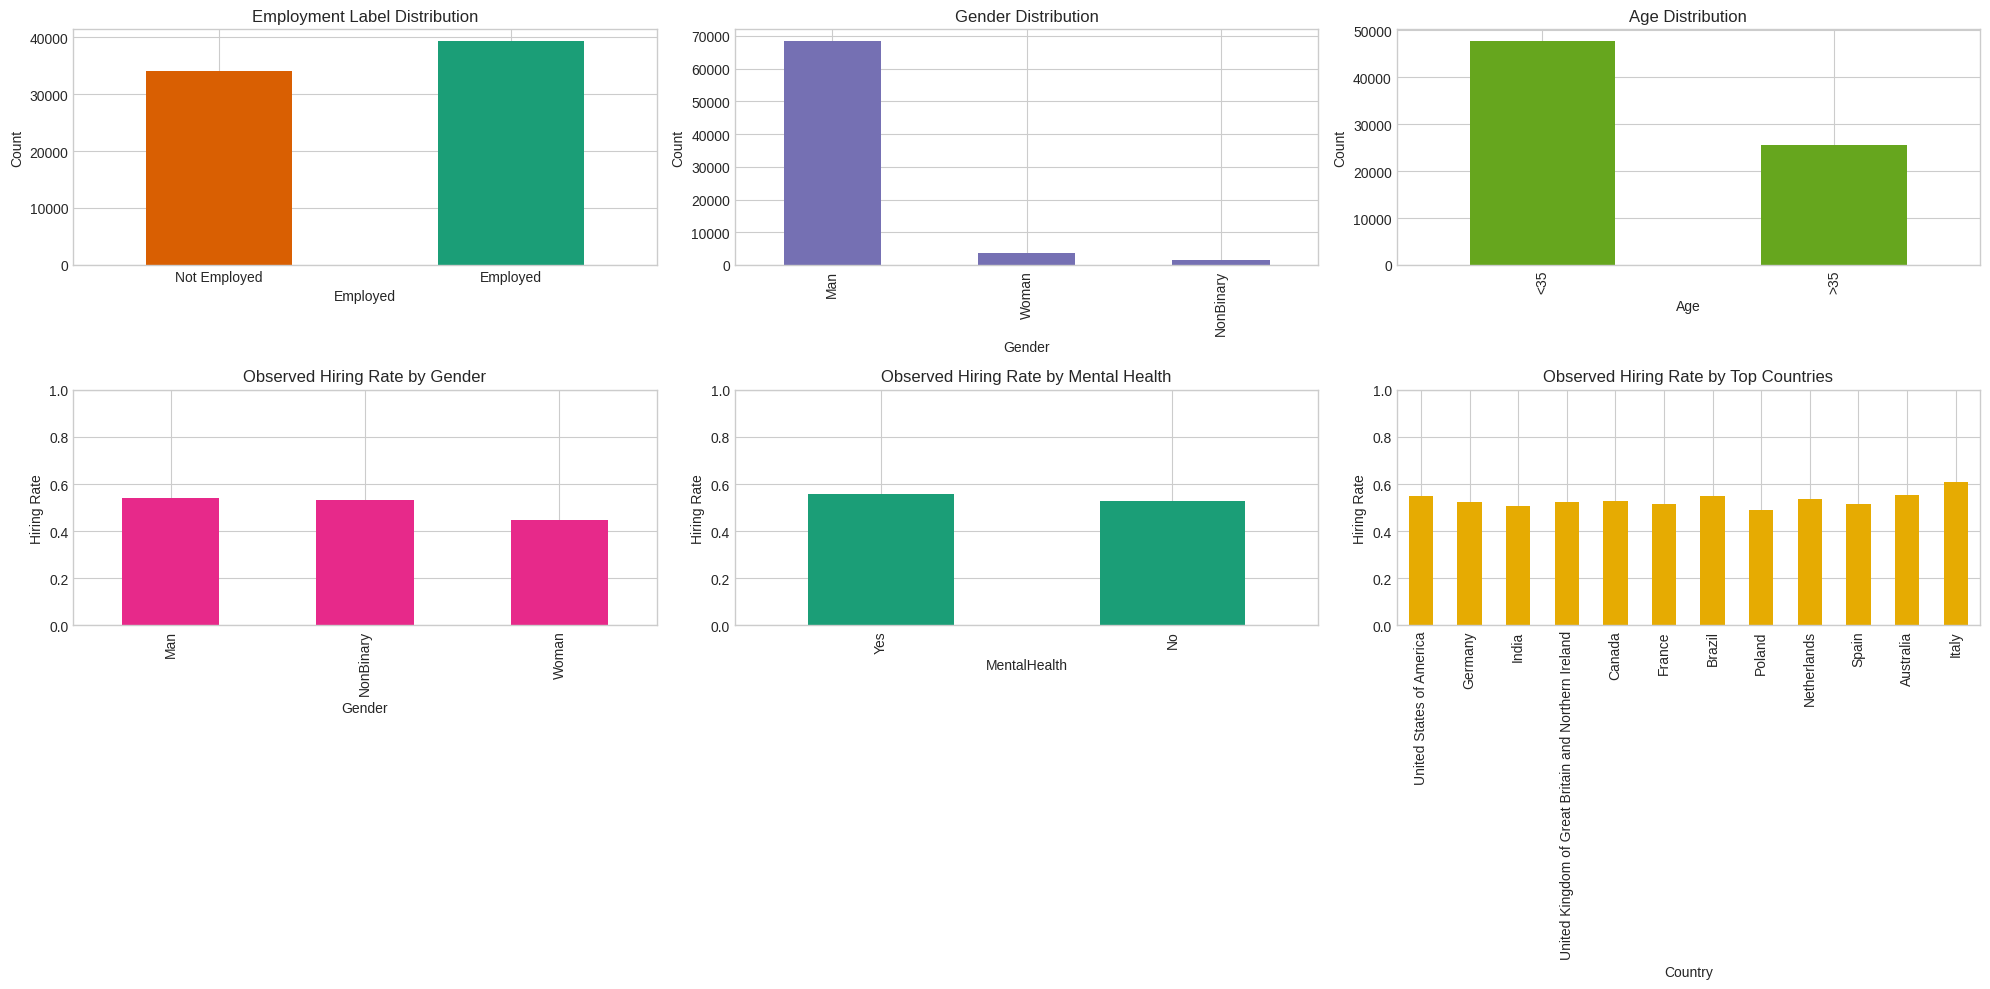

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(20, 10))

clean_df["Employed"].value_counts().sort_index().plot(
    kind="bar", ax=axes[0, 0], color=["#d95f02", "#1b9e77"], title="Employment Label Distribution"
)
axes[0, 0].set_xticklabels(["Not Employed", "Employed"], rotation=0)
axes[0, 0].set_ylabel("Count")

clean_df["Gender"].value_counts().plot(
    kind="bar", ax=axes[0, 1], color="#7570b3", title="Gender Distribution"
)
axes[0, 1].set_ylabel("Count")

clean_df["Age"].value_counts().plot(
    kind="bar", ax=axes[0, 2], color="#66a61e", title="Age Distribution"
)
axes[0, 2].set_ylabel("Count")

clean_df.groupby("Gender")["Employed"].mean().sort_values(ascending=False).plot(
    kind="bar", ax=axes[1, 0], color="#e7298a", title="Observed Hiring Rate by Gender"
)
axes[1, 0].set_ylim(0, 1)
axes[1, 0].set_ylabel("Hiring Rate")

clean_df.groupby("MentalHealth")["Employed"].mean().sort_values(ascending=False).plot(
    kind="bar", ax=axes[1, 1], color="#1b9e77", title="Observed Hiring Rate by Mental Health"
)
axes[1, 1].set_ylim(0, 1)
axes[1, 1].set_ylabel("Hiring Rate")

top_country_rates = (
    clean_df.groupby("Country")["Employed"]
    .agg(["mean", "count"])
    .query("count >= @MIN_COUNTRY_COUNT")
    .sort_values("count", ascending=False)
    .head(TOP_COUNTRIES)
)
top_country_rates["mean"].plot(
    kind="bar", ax=axes[1, 2], color="#e6ab02", title="Observed Hiring Rate by Top Countries"
)
axes[1, 2].set_ylim(0, 1)
axes[1, 2].set_ylabel("Hiring Rate")

plt.tight_layout()
fig.savefig(OUTPUT_DIR / "eda_hiring_bias_overview.png", dpi=180, bbox_inches="tight")
plt.show()


This chart cell recreates the descriptive side of the project. The first row shows how imbalanced the sample is across labels and demographic groups, while the second row compares the observed hiring rate across protected or potentially sensitive dimensions.


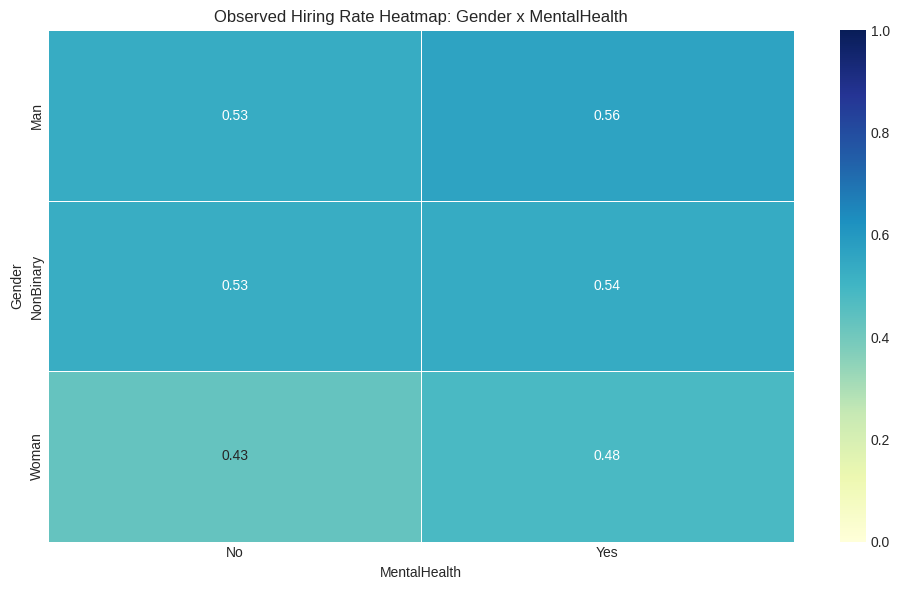

In [ ]:
interaction_table = clean_df.groupby(["Gender", "MentalHealth"])["Employed"].mean().unstack(fill_value=np.nan)

plt.figure(figsize=(10, 6))
sns.heatmap(
    interaction_table,
    annot=True,
    fmt=".2f",
    cmap="YlGnBu",
    vmin=0,
    vmax=1,
    linewidths=0.5,
)
plt.title("Hiring Rate Heatmap: Gender x MentalHealth")
plt.xlabel("MentalHealth")
plt.ylabel("Gender")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "eda_gender_mental_health_heatmap.png", dpi=180, bbox_inches="tight")
plt.show()


This heatmap checks whether disparities become sharper when two attributes are considered together. It is useful because group-level fairness gaps can sometimes look mild in isolation but become clearer at the intersection of multiple traits.


## 3. AIF360 and Modeling Helpers


In [ ]:
def compute_fairness_metrics(
    dataset_true: BinaryLabelDataset,
    dataset_pred: BinaryLabelDataset,
    unprivileged_groups: list[dict[str, int]],
    privileged_groups: list[dict[str, int]],
) -> dict[str, float]:
    cm = ClassificationMetric(
        dataset_true,
        dataset_pred,
        unprivileged_groups=unprivileged_groups,
        privileged_groups=privileged_groups,
    )

    return {
        "Balanced accuracy": 0.5 * (cm.true_positive_rate() + cm.true_negative_rate()),
        "Statistical parity difference": cm.statistical_parity_difference(),
        "Disparate impact": cm.disparate_impact(),
        "Average odds difference": cm.average_odds_difference(),
        "Equal opportunity difference": cm.equal_opportunity_difference(),
        "Theil index": cm.theil_index(),
    }


def fit_with_optional_weights(model, x_train: np.ndarray, y_train: np.ndarray, sample_weights=None) -> None:
    if sample_weights is None:
        model.fit(x_train, y_train)
        return

    if "sample_weight" in inspect.signature(model.fit).parameters:
        model.fit(x_train, y_train, sample_weight=sample_weights)
        return

    model.fit(x_train, y_train)


def prediction_scores(model, x_input: np.ndarray) -> np.ndarray:
    if hasattr(model, "predict_proba"):
        return model.predict_proba(x_input)[:, 1]

    if hasattr(model, "decision_function"):
        raw_scores = model.decision_function(x_input)
        min_score = np.min(raw_scores)
        max_score = np.max(raw_scores)
        if max_score == min_score:
            return np.full_like(raw_scores, 0.5, dtype=float)
        return (raw_scores - min_score) / (max_score - min_score)

    return model.predict(x_input).astype(float)


def build_models(random_state: int = RANDOM_STATE) -> dict[str, object]:
    return {
        "Logistic Regression": LogisticRegression(max_iter=2000, random_state=random_state),
        "Random Forest": RandomForestClassifier(
            n_estimators=300,
            random_state=random_state,
            n_jobs=RF_N_JOBS,
        ),
        "Decision Tree": DecisionTreeClassifier(random_state=random_state),
        "KNN": KNeighborsClassifier(n_neighbors=11),
        "Linear SVC": LinearSVC(random_state=random_state, dual="auto", max_iter=5000),
    }


def summarize_dataset_fairness(
    dataset: BinaryLabelDataset,
    unprivileged_groups: list[dict[str, int]],
    privileged_groups: list[dict[str, int]],
) -> pd.Series:
    metric = BinaryLabelDatasetMetric(
        dataset,
        unprivileged_groups=unprivileged_groups,
        privileged_groups=privileged_groups,
    )

    return pd.Series(
        {
            "Statistical parity difference": metric.mean_difference(),
            "Disparate impact": metric.disparate_impact(),
            "Base rate privileged": metric.base_rate(privileged=True),
            "Base rate unprivileged": metric.base_rate(privileged=False),
        }
    )


def train_and_evaluate(
    model,
    dataset_train: BinaryLabelDataset,
    dataset_valid: BinaryLabelDataset,
    dataset_test: BinaryLabelDataset,
    privileged_groups: list[dict[str, int]],
    unprivileged_groups: list[dict[str, int]],
    sample_weights=None,
) -> tuple[dict[str, float], np.ndarray]:
    scaler = StandardScaler()
    x_train = scaler.fit_transform(dataset_train.features)
    y_train = dataset_train.labels.ravel().astype(int)

    fit_with_optional_weights(model, x_train, y_train, sample_weights=sample_weights)

    x_valid = scaler.transform(dataset_valid.features)
    y_valid = dataset_valid.labels.ravel().astype(int)
    valid_scores = prediction_scores(model, x_valid)

    thresholds = np.linspace(0.05, 0.95, 91)
    best_threshold = 0.5
    best_bacc = -1.0

    for threshold in thresholds:
        valid_preds = (valid_scores >= threshold).astype(int)
        bacc = balanced_accuracy_score(y_valid, valid_preds)
        if bacc > best_bacc:
            best_bacc = bacc
            best_threshold = float(threshold)

    x_test = scaler.transform(dataset_test.features)
    y_test = dataset_test.labels.ravel().astype(int)
    test_scores = prediction_scores(model, x_test)
    y_pred = (test_scores >= best_threshold).astype(int)

    dataset_test_pred = dataset_test.copy(deepcopy=True)
    dataset_test_pred.labels = y_pred.reshape(-1, 1).astype(float)

    metrics = compute_fairness_metrics(
        dataset_true=dataset_test,
        dataset_pred=dataset_test_pred,
        unprivileged_groups=unprivileged_groups,
        privileged_groups=privileged_groups,
    )
    metrics["Accuracy"] = accuracy_score(y_test, y_pred)
    metrics["Precision"] = precision_score(y_test, y_pred, zero_division=0)
    metrics["Recall"] = recall_score(y_test, y_pred, zero_division=0)
    metrics["F1"] = f1_score(y_test, y_pred, zero_division=0)
    metrics["Threshold"] = best_threshold
    return metrics, y_pred


This helper block contains the same core mechanics from the original project: fairness-metric computation with AIF360, optional weighting support for reweighing, score extraction for threshold tuning, and the five-model training loop. Each model is tuned on the validation split by balanced accuracy before being evaluated on the held-out test split.


In [ ]:
def normalized_indicator(series: pd.Series, privileged_values: set[str]) -> pd.Series:
    normalized = series.fillna("Unknown").astype(str).str.strip().str.lower()
    privileged_lookup = {value.lower() for value in privileged_values}
    return normalized.isin(privileged_lookup).astype(float)


PROTECTED_CONFIGS = {
    "Gender": {
        "raw_column": "Gender",
        "protected_column": "Is_Man",
        "privileged_values": {"Man"},
        "privileged_label": "Man",
        "unprivileged_label": "Not Man",
        "group_order": ["Man", "Woman", "NonBinary", "Unknown"],
    },
    "Age": {
        "raw_column": "Age",
        "protected_column": "Is_Under35",
        "privileged_values": {"<35"},
        "privileged_label": "<35",
        "unprivileged_label": "Not <35",
        "group_order": ["<35", ">35", "Unknown"],
    },
    "MentalHealth": {
        "raw_column": "MentalHealth",
        "protected_column": "Is_MH_No",
        "privileged_values": {"No"},
        "privileged_label": "No",
        "unprivileged_label": "Not No",
        "group_order": ["No", "Yes", "Unknown"],
    },
    "Accessibility": {
        "raw_column": "Accessibility",
        "protected_column": "Is_Access_No",
        "privileged_values": {"No"},
        "privileged_label": "No",
        "unprivileged_label": "Not No",
        "group_order": ["No", "Yes", "Unknown"],
    },
    "Country": {
        "raw_column": "Country",
        "protected_column": "Is_Priv_Country",
        "privileged_values": {COUNTRY_PRIVILEGED},
        "privileged_label": COUNTRY_PRIVILEGED,
        "unprivileged_label": "Other Countries",
        "group_order": None,
    },
}


def plot_model_comparison(before_df: pd.DataFrame, after_df: pd.DataFrame, title: str, save_path: Path | None = None) -> None:
    labels = before_df.index.tolist()
    x = np.arange(len(labels))
    width = 0.38
    metrics_to_plot = [
        ("Statistical parity difference", "SPD (closer to 0 is fairer)", 0.0),
        ("Disparate impact", "DI (closer to 1 is fairer)", 1.0),
        ("Accuracy", "Accuracy", None),
    ]

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    for ax, (metric_name, ylabel, reference) in zip(axes, metrics_to_plot):
        ax.bar(x - width / 2, before_df[metric_name].values, width=width, label="Before Reweighing", color="#d95f02")
        ax.bar(x + width / 2, after_df[metric_name].values, width=width, label="After Reweighing", color="#1b9e77")
        if reference is not None:
            ax.axhline(reference, color="black", linestyle="--", linewidth=1.0, alpha=0.7)
        ax.set_xticks(x)
        ax.set_xticklabels(labels, rotation=20, ha="right")
        ax.set_ylabel(ylabel)
        ax.set_title(metric_name)
        ax.grid(axis="y", alpha=0.25)

    handles, legend_labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, legend_labels, loc="upper center", ncol=2, bbox_to_anchor=(0.5, 1.04))
    fig.suptitle(title, y=1.08, fontsize=14)
    fig.tight_layout()
    if save_path is not None:
        fig.savefig(save_path, dpi=180, bbox_inches="tight")
    plt.show()


def plot_group_prediction_rates(
    pred_df: pd.DataFrame,
    group_col: str,
    title: str,
    group_order: list[str] | None = None,
    save_path: Path | None = None,
) -> None:
    grouped = pred_df.groupby(group_col)[["Pred_Before", "Pred_After"]].mean()
    if group_order is not None:
        existing = [value for value in group_order if value in grouped.index]
        grouped = grouped.reindex(existing)

    labels = grouped.index.astype(str).tolist()
    x = np.arange(len(labels))
    width = 0.38

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.bar(x - width / 2, grouped["Pred_Before"].values, width=width, label="Before Reweighing", color="#7570b3")
    ax.bar(x + width / 2, grouped["Pred_After"].values, width=width, label="After Reweighing", color="#66a61e")
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=20, ha="right")
    ax.set_ylim(0, 1)
    ax.set_ylabel("Predicted Hiring Rate")
    ax.set_title(title)
    ax.grid(axis="y", alpha=0.25)
    ax.legend()
    plt.tight_layout()
    if save_path is not None:
        fig.savefig(save_path, dpi=180, bbox_inches="tight")
    plt.show()


This cell defines the protected-group configurations used throughout the notebook. It also adds reusable plotting helpers so each fairness analysis can be reported consistently across metrics, groups, and before/after mitigation views.


In [ ]:
def plot_prediction_interaction_heatmaps(
    pred_df: pd.DataFrame,
    row_col: str,
    col_col: str,
    save_path: Path | None = None,
) -> None:
    before_tab = pred_df.groupby([row_col, col_col])["Pred_Before"].mean().unstack(fill_value=np.nan)
    after_tab = pred_df.groupby([row_col, col_col])["Pred_After"].mean().unstack(fill_value=np.nan)

    row_values = sorted(set(before_tab.index).union(after_tab.index))
    col_values = sorted(set(before_tab.columns).union(after_tab.columns))
    before_tab = before_tab.reindex(index=row_values, columns=col_values)
    after_tab = after_tab.reindex(index=row_values, columns=col_values)

    fig, axes = plt.subplots(1, 2, figsize=(16, 6), constrained_layout=True)
    for ax, table, title in [
        (axes[0], before_tab, "Before Reweighing"),
        (axes[1], after_tab, "After Reweighing"),
    ]:
        sns.heatmap(table, annot=True, fmt=".2f", cmap="YlGnBu", vmin=0, vmax=1, linewidths=0.5, ax=ax)
        ax.set_title(f"Predicted Hiring Rate: {title}")
        ax.set_xlabel(col_col)
        ax.set_ylabel(row_col)

    if save_path is not None:
        fig.savefig(save_path, dpi=180, bbox_inches="tight")
    plt.show()


def run_protected_attribute_analysis(
    clean_df: pd.DataFrame,
    base_analysis_df: pd.DataFrame,
    config_name: str,
    random_state: int = RANDOM_STATE,
) -> dict:
    config = PROTECTED_CONFIGS[config_name]
    analysis_df = base_analysis_df.copy()

    protected_indicator = normalized_indicator(
        clean_df[config["raw_column"]],
        config["privileged_values"],
    )

    analysis_df[config["protected_column"]] = protected_indicator.astype(float)

    bld = BinaryLabelDataset(
        df=analysis_df,
        label_names=["Employed"],
        favorable_label=1.0,
        unfavorable_label=0.0,
        protected_attribute_names=[config["protected_column"]],
    )

    privileged_groups = [{config["protected_column"]: 1}]
    unprivileged_groups = [{config["protected_column"]: 0}]

    full_dataset_fairness = summarize_dataset_fairness(
        bld,
        unprivileged_groups=unprivileged_groups,
        privileged_groups=privileged_groups,
    )

    dataset_train, dataset_valid, dataset_test = bld.split([0.7, 0.85], shuffle=True, seed=random_state)

    before_results = {}
    before_preds = {}
    for model_name, model in build_models(random_state).items():
        metrics, preds = train_and_evaluate(
            model=clone(model),
            dataset_train=dataset_train,
            dataset_valid=dataset_valid,
            dataset_test=dataset_test,
            privileged_groups=privileged_groups,
            unprivileged_groups=unprivileged_groups,
            sample_weights=None,
        )
        before_results[model_name] = metrics
        before_preds[model_name] = preds

    rw = Reweighing(unprivileged_groups=unprivileged_groups, privileged_groups=privileged_groups)
    dataset_rw_train = rw.fit_transform(dataset_train)

    train_fairness_before = summarize_dataset_fairness(
        dataset_train,
        unprivileged_groups=unprivileged_groups,
        privileged_groups=privileged_groups,
    )
    train_fairness_after = summarize_dataset_fairness(
        dataset_rw_train,
        unprivileged_groups=unprivileged_groups,
        privileged_groups=privileged_groups,
    )

    after_results = {}
    after_preds = {}
    for model_name, model in build_models(random_state).items():
        metrics, preds = train_and_evaluate(
            model=clone(model),
            dataset_train=dataset_rw_train,
            dataset_valid=dataset_valid,
            dataset_test=dataset_test,
            privileged_groups=privileged_groups,
            unprivileged_groups=unprivileged_groups,
            sample_weights=dataset_rw_train.instance_weights,
        )
        after_results[model_name] = metrics
        after_preds[model_name] = preds

    before_df = pd.DataFrame(before_results).T
    after_df = pd.DataFrame(after_results).T

    comparison_df = pd.DataFrame(index=before_df.index)
    comparison_df["SPD_before"] = before_df["Statistical parity difference"]
    comparison_df["SPD_after"] = after_df["Statistical parity difference"]
    comparison_df["|SPD| improvement"] = comparison_df["SPD_before"].abs() - comparison_df["SPD_after"].abs()
    comparison_df["DI_before"] = before_df["Disparate impact"]
    comparison_df["DI_after"] = after_df["Disparate impact"]
    comparison_df["Accuracy_before"] = before_df["Accuracy"]
    comparison_df["Accuracy_after"] = after_df["Accuracy"]

    best_model = before_df["Balanced accuracy"].idxmax()
    test_indices = [int(index) for index in dataset_test.instance_names]

    pred_df = clean_df.iloc[test_indices][RAW_AUX_COLS].copy().reset_index(drop=True)
    pred_df["Protected_Group"] = np.where(
        protected_indicator.iloc[test_indices].astype(int) == 1,
        config["privileged_label"],
        config["unprivileged_label"],
    )
    pred_df["Pred_Before"] = before_preds[best_model].astype(float)
    pred_df["Pred_After"] = after_preds[best_model].astype(float)

    return {
        "config_name": config_name,
        "config": config,
        "full_dataset_fairness": full_dataset_fairness,
        "train_fairness_before": train_fairness_before,
        "train_fairness_after": train_fairness_after,
        "before_df": before_df,
        "after_df": after_df,
        "comparison_df": comparison_df,
        "best_model": best_model,
        "pred_df": pred_df,
    }


This cell wraps the full fairness pipeline into reusable functions. The `run_protected_attribute_analysis` function builds the AIF360 dataset for one protected attribute, trains all five models, applies reweighing on the training split, retrains the models with sample weights, and returns both the metrics and the prediction-level outputs needed for plots.


## 4. Fairness Analysis for Gender


In [ ]:
gender_results = run_protected_attribute_analysis(clean_df, base_analysis_df, "Gender", random_state=RANDOM_STATE)

gender_dataset_summary = pd.concat(
    [
        gender_results["full_dataset_fairness"].rename("Full dataset before mitigation"),
        gender_results["train_fairness_before"].rename("Train split before reweighing"),
        gender_results["train_fairness_after"].rename("Train split after reweighing"),
    ],
    axis=1,
)

print("Best baseline model:", gender_results["best_model"])
display(gender_dataset_summary)

summary_cols = [
    "Balanced accuracy",
    "Statistical parity difference",
    "Disparate impact",
    "Average odds difference",
    "Equal opportunity difference",
    "Accuracy",
    "F1",
    "Threshold",
]

display(gender_results["before_df"][summary_cols].round(4))
display(gender_results["after_df"][summary_cols].round(4))
display(gender_results["comparison_df"].round(4))


Best baseline model: Linear SVC


,Full dataset before mitigation,Train split before reweighing,Train split after reweighing
Statistical parity difference,-0.0683,-0.0744,0.0000
Disparate impact,0.8737,0.8628,1.0000
Base rate privileged,0.5408,0.5422,0.5374
Base rate unprivileged,0.4725,0.4679,0.5374


,Balanced accuracy,Statistical parity difference,Disparate impact,Average odds difference,Equal opportunity difference,Accuracy,F1,Threshold
Logistic Regression,0.7825,-0.0785,0.8558,-0.0566,-0.0541,0.7838,0.7981,0.4900
Random Forest,0.7618,-0.0824,0.8487,-0.0621,-0.0495,0.7632,0.7788,0.5300
Decision Tree,0.7070,-0.0884,0.8344,-0.0725,-0.0896,0.7079,0.7244,0.5100
KNN,0.7571,-0.1063,0.8096,-0.0864,-0.1042,0.7593,0.7776,0.4600
Linear SVC,0.7827,-0.0841,0.8442,-0.0622,-0.0599,0.7837,0.7970,0.1500


,Balanced accuracy,Statistical parity difference,Disparate impact,Average odds difference,Equal opportunity difference,Accuracy,F1,Threshold
Logistic Regression,0.7843,-0.0249,0.9526,-0.0029,0.0168,0.7847,0.7962,0.5100
Random Forest,0.7631,-0.0715,0.8703,-0.0511,-0.0235,0.7650,0.7820,0.5200
Decision Tree,0.7052,-0.0808,0.8482,-0.0650,-0.0706,0.7061,0.7225,0.5000
KNN,0.7571,-0.1063,0.8096,-0.0864,-0.1042,0.7593,0.7776,0.4600
Linear SVC,0.7836,-0.0262,0.9516,-0.0042,0.0164,0.7848,0.7990,0.1500


,SPD_before,SPD_after,|SPD| improvement,DI_before,DI_after,Accuracy_before,Accuracy_after
Logistic Regression,-0.0785,-0.0249,0.0535,0.8558,0.9526,0.7838,0.7847
Random Forest,-0.0824,-0.0715,0.0109,0.8487,0.8703,0.7632,0.7650
Decision Tree,-0.0884,-0.0808,0.0076,0.8344,0.8482,0.7079,0.7061
KNN,-0.1063,-0.1063,0.0000,0.8096,0.8096,0.7593,0.7593
Linear SVC,-0.0841,-0.0262,0.0579,0.8442,0.9516,0.7837,0.7848


This cell executes the full AIF360 workflow with `Gender` as the protected attribute, where `Man` is treated as the privileged group to match the current project. The first table shows dataset-level disparity before mitigation and how reweighing changes the fairness profile of the training split, while the later tables compare each model before and after mitigation.


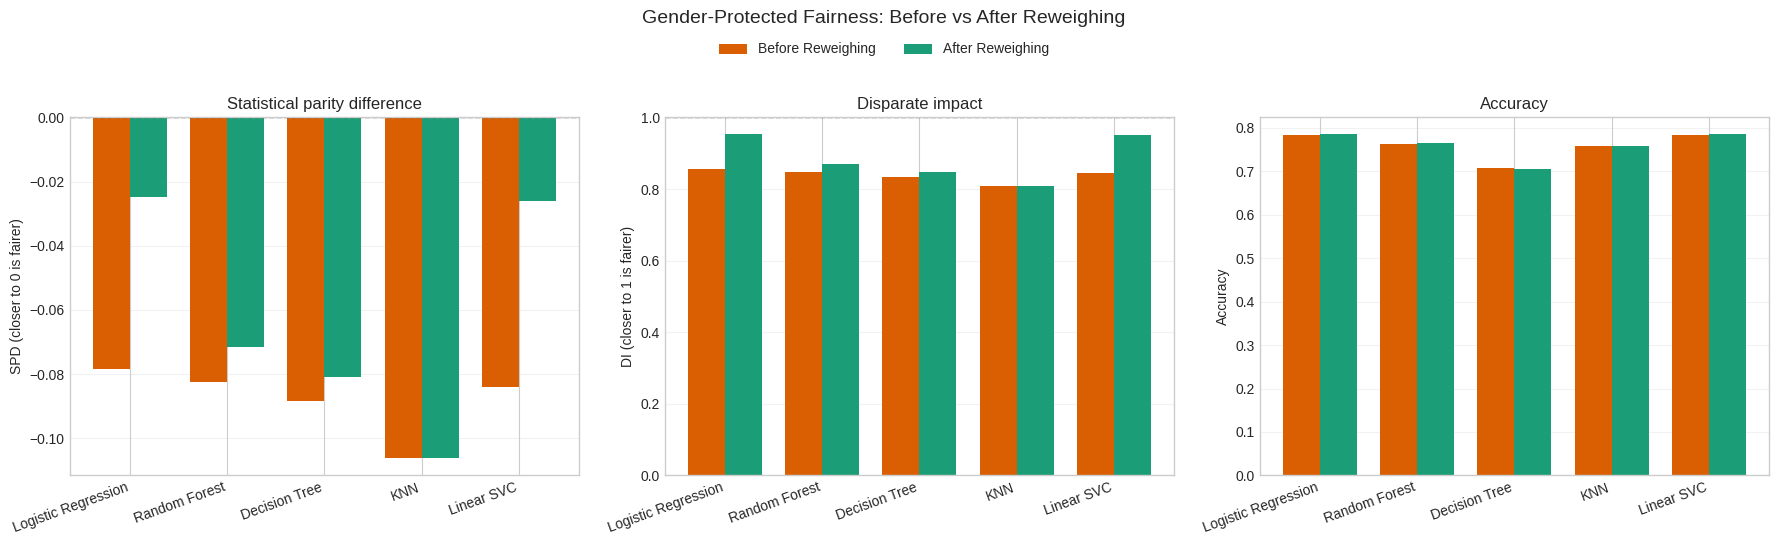

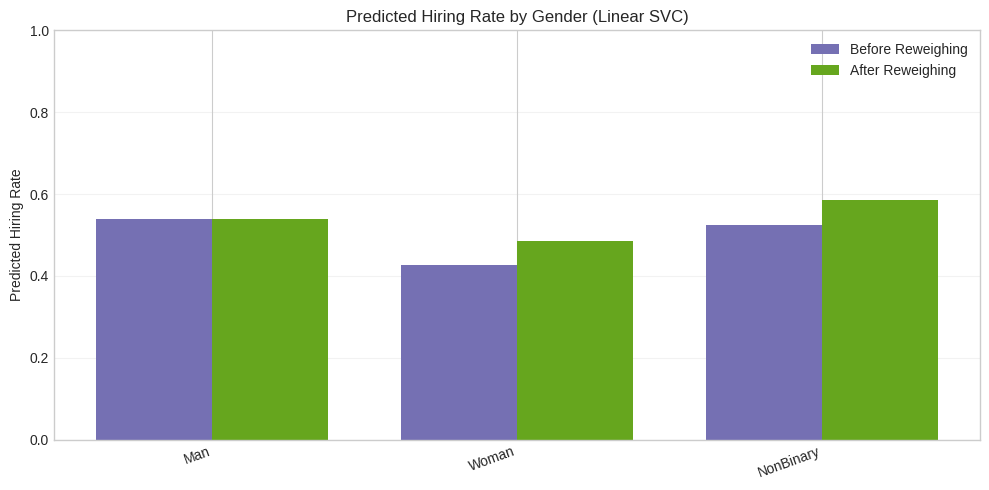

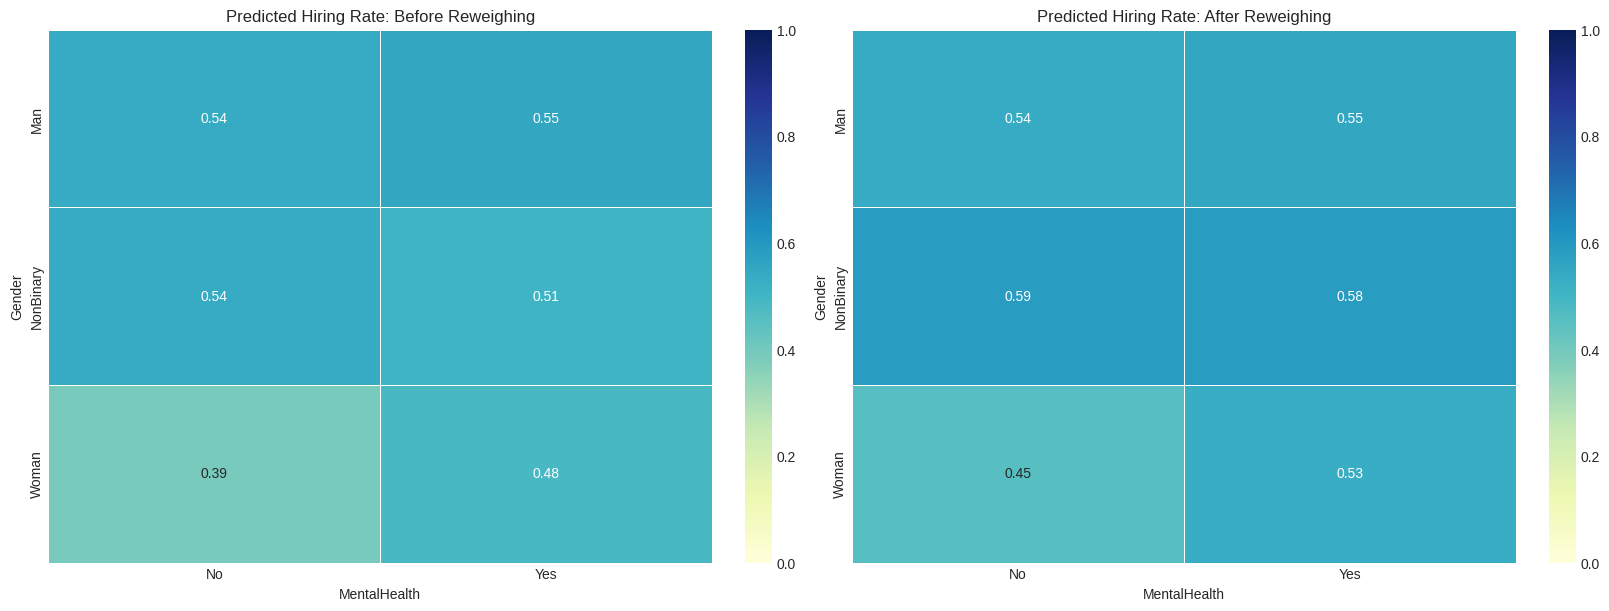

In [ ]:
plot_model_comparison(
    gender_results["before_df"],
    gender_results["after_df"],
    title="Gender-Protected Fairness: Before vs After Reweighing",
    save_path=OUTPUT_DIR / "gender_model_comparison.png",
)

plot_group_prediction_rates(
    gender_results["pred_df"],
    group_col="Gender",
    title=f"Predicted Hiring Rate by Gender ({gender_results['best_model']})",
    group_order=gender_results["config"]["group_order"],
    save_path=OUTPUT_DIR / "gender_prediction_rates.png",
)

plot_prediction_interaction_heatmaps(
    gender_results["pred_df"],
    row_col="Gender",
    col_col="MentalHealth",
    save_path=OUTPUT_DIR / "gender_mental_health_prediction_heatmaps.png",
)


These plots show the practical effect of reweighing on the gender analysis. The first figure compares fairness and accuracy across all models, the second focuses on predicted hiring rates by gender for the strongest baseline model, and the third checks whether the before/after shift is also visible at the intersection of gender and mental-health status.


## 5. Threshold Analysis for Logistic Regression on Gender


,Balanced accuracy,Statistical parity difference,Disparate impact,Average odds difference,Equal opportunity difference,Theil index,Threshold,Accuracy
0,0.5380,-0.0312,0.9677,-0.0282,0.0000,0.0591,0.0500,0.5677
1,0.5713,-0.0421,0.9550,-0.0365,0.0005,0.0599,0.0750,0.5988
2,0.6047,-0.0466,0.9484,-0.0384,0.0033,0.0612,0.1000,0.6299
3,0.6365,-0.0516,0.9407,-0.0410,-0.0011,0.0626,0.1250,0.6594
4,0.6630,-0.0691,0.9177,-0.0564,-0.0058,0.0647,0.1500,0.6838


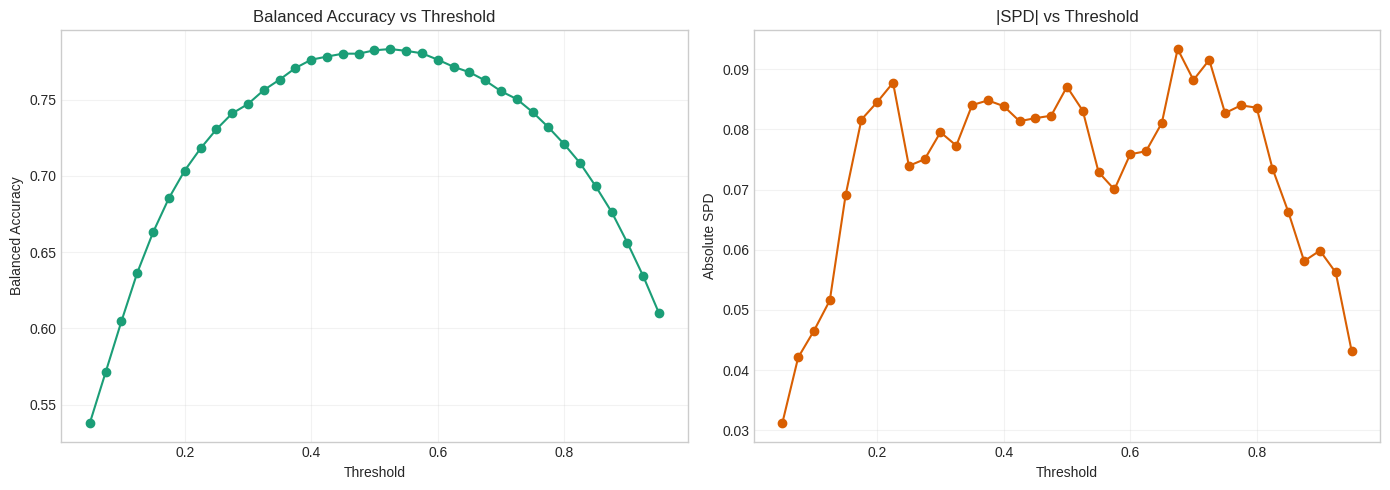

In [ ]:
def threshold_sweep_for_gender(
    dataset_results: dict,
    thresholds: np.ndarray | None = None,
) -> pd.DataFrame:
    if thresholds is None:
        thresholds = np.linspace(0.05, 0.95, 37)

    config = dataset_results["config"]
    analysis_df = base_analysis_df.copy()
    analysis_df[config["protected_column"]] = normalized_indicator(
        clean_df[config["raw_column"]],
        config["privileged_values"],
    ).astype(float)

    bld = BinaryLabelDataset(
        df=analysis_df,
        label_names=["Employed"],
        favorable_label=1.0,
        unfavorable_label=0.0,
        protected_attribute_names=[config["protected_column"]],
    )

    privileged_groups = [{config["protected_column"]: 1}]
    unprivileged_groups = [{config["protected_column"]: 0}]
    dataset_train, dataset_valid, dataset_test = bld.split([0.7, 0.85], shuffle=True, seed=RANDOM_STATE)

    model = LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)
    scaler = StandardScaler()
    x_train = scaler.fit_transform(dataset_train.features)
    y_train = dataset_train.labels.ravel().astype(int)
    model.fit(x_train, y_train)

    x_test = scaler.transform(dataset_test.features)
    y_test = dataset_test.labels.ravel().astype(int)
    test_scores = prediction_scores(model, x_test)

    rows = []
    for threshold in thresholds:
        y_pred = (test_scores >= threshold).astype(int)
        dataset_test_pred = dataset_test.copy(deepcopy=True)
        dataset_test_pred.labels = y_pred.reshape(-1, 1).astype(float)

        fairness = compute_fairness_metrics(
            dataset_true=dataset_test,
            dataset_pred=dataset_test_pred,
            unprivileged_groups=unprivileged_groups,
            privileged_groups=privileged_groups,
        )
        fairness["Threshold"] = threshold
        fairness["Accuracy"] = accuracy_score(y_test, y_pred)
        fairness["Balanced accuracy"] = balanced_accuracy_score(y_test, y_pred)
        rows.append(fairness)

    return pd.DataFrame(rows)


threshold_df = threshold_sweep_for_gender(gender_results)
display(threshold_df.head())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(threshold_df["Threshold"], threshold_df["Balanced accuracy"], marker="o", color="#1b9e77")
axes[0].set_title("Balanced Accuracy vs Threshold")
axes[0].set_xlabel("Threshold")
axes[0].set_ylabel("Balanced Accuracy")
axes[0].grid(alpha=0.25)

axes[1].plot(
    threshold_df["Threshold"],
    threshold_df["Statistical parity difference"].abs(),
    marker="o",
    color="#d95f02",
)
axes[1].set_title("|SPD| vs Threshold")
axes[1].set_xlabel("Threshold")
axes[1].set_ylabel("Absolute SPD")
axes[1].grid(alpha=0.25)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "gender_threshold_sweep.png", dpi=180, bbox_inches="tight")
plt.show()


This section mirrors the more explanatory style of the COMPAS notebook by making the threshold trade-off visible. Lower absolute SPD is better for parity, while higher balanced accuracy is better for predictive utility, so the two curves reveal where the classification threshold moves the system toward or away from fairness.


## 6. Multi-Attribute Fairness Analysis


In [ ]:
all_results = {"Gender": gender_results}

for protected_name in ["Age", "MentalHealth", "Accessibility", "Country"]:
    print(f"Running {protected_name} analysis...")
    all_results[protected_name] = run_protected_attribute_analysis(
        clean_df,
        base_analysis_df,
        protected_name,
        random_state=RANDOM_STATE,
    )

summary_rows = []
for protected_name, result in all_results.items():
    best_model = result["best_model"]
    summary_rows.append(
        {
            "Protected Attribute": protected_name,
            "Privileged Group": result["config"]["privileged_label"],
            "Best Baseline Model": best_model,
            "Dataset SPD Before": result["full_dataset_fairness"]["Statistical parity difference"],
            "Dataset DI Before": result["full_dataset_fairness"]["Disparate impact"],
            "Best Model Accuracy Before": result["before_df"].loc[best_model, "Accuracy"],
            "Best Model Accuracy After": result["after_df"].loc[best_model, "Accuracy"],
            "Best Model SPD Before": result["before_df"].loc[best_model, "Statistical parity difference"],
            "Best Model SPD After": result["after_df"].loc[best_model, "Statistical parity difference"],
            "Best Model DI Before": result["before_df"].loc[best_model, "Disparate impact"],
            "Best Model DI After": result["after_df"].loc[best_model, "Disparate impact"],
            "|SPD| Improvement": (
                abs(result["before_df"].loc[best_model, "Statistical parity difference"])
                - abs(result["after_df"].loc[best_model, "Statistical parity difference"])
            ),
        }
    )

multi_attribute_summary = pd.DataFrame(summary_rows).sort_values("Protected Attribute").reset_index(drop=True)
display(multi_attribute_summary.round(4))


Running Age analysis...
Running MentalHealth analysis...
Running Accessibility analysis...
Running Country analysis...


,Protected Attribute,Privileged Group,Best Baseline Model,Dataset SPD Before,Dataset DI Before,Best Model Accuracy Before,Best Model Accuracy After,Best Model SPD Before,Best Model SPD After,Best Model DI Before,Best Model DI After,|SPD| Improvement
0,Accessibility,No,Linear SVC,0.0318,1.0595,0.7838,0.7838,0.0145,-0.0129,1.0271,0.9759,0.0016
1,Age,<35,Linear SVC,-0.0317,0.9422,0.7838,0.7830,-0.0556,-0.0330,0.8998,0.9397,0.0225
2,Country,United States of America,Logistic Regression,-0.0183,0.9667,0.7859,0.7851,-0.0104,0.0088,0.9810,1.0167,0.0015
3,Gender,Man,Linear SVC,-0.0683,0.8737,0.7837,0.7848,-0.0841,-0.0262,0.8442,0.9516,0.0579
4,MentalHealth,No,Linear SVC,0.0269,1.0508,0.7838,0.7832,0.0114,-0.0139,1.0215,0.9765,-0.0025


This cell repeats the same pipeline for all protected attributes in the project and compresses the outcomes into a single summary table. The table focuses on the best baseline model for each attribute so the before/after comparison stays consistent with the original plotting scripts.


### Attribute-Specific Model Comparison Figures

The next set of figures recreates the report-style before/after bar charts for every protected attribute used in the project. Each chart compares statistical parity difference, disparate impact, and accuracy across the five machine-learning models so the mitigation effect is easy to read visually.


### Gender Bias

This figure compares model fairness and accuracy before and after AIF360 reweighing when `Gender` is the protected attribute. In this setup, `Man` is treated as the privileged group and all other gender values are treated as the unprivileged group.


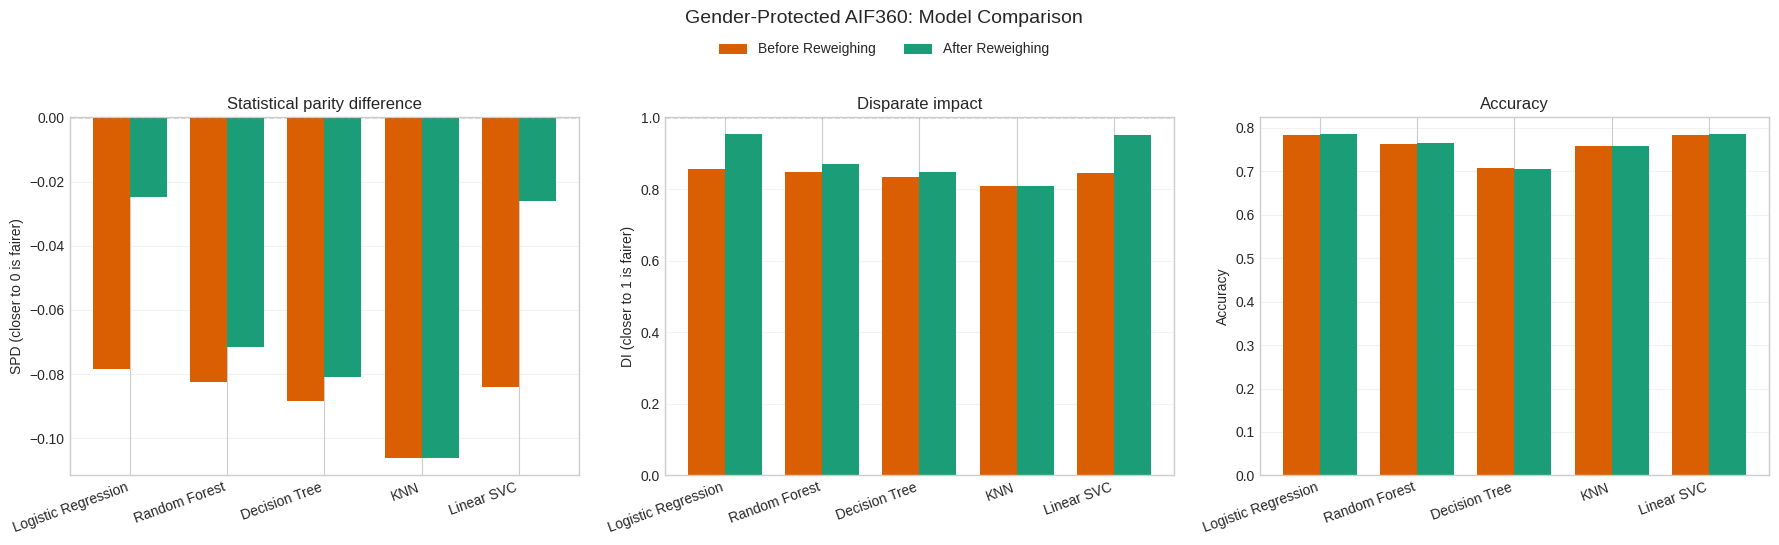

In [ ]:
plot_model_comparison(
    all_results["Gender"]["before_df"],
    all_results["Gender"]["after_df"],
    title="Gender-Protected AIF360: Model Comparison",
    save_path=OUTPUT_DIR / "gender_model_comparison_report_style.png",
)


### Age Bias

This figure compares model fairness and accuracy before and after AIF360 reweighing when `Age` is the protected attribute. The notebook follows the same project convention as your scripts: applicants under 35 (`<35`) are treated as the privileged group and all other age values are treated as the unprivileged group.


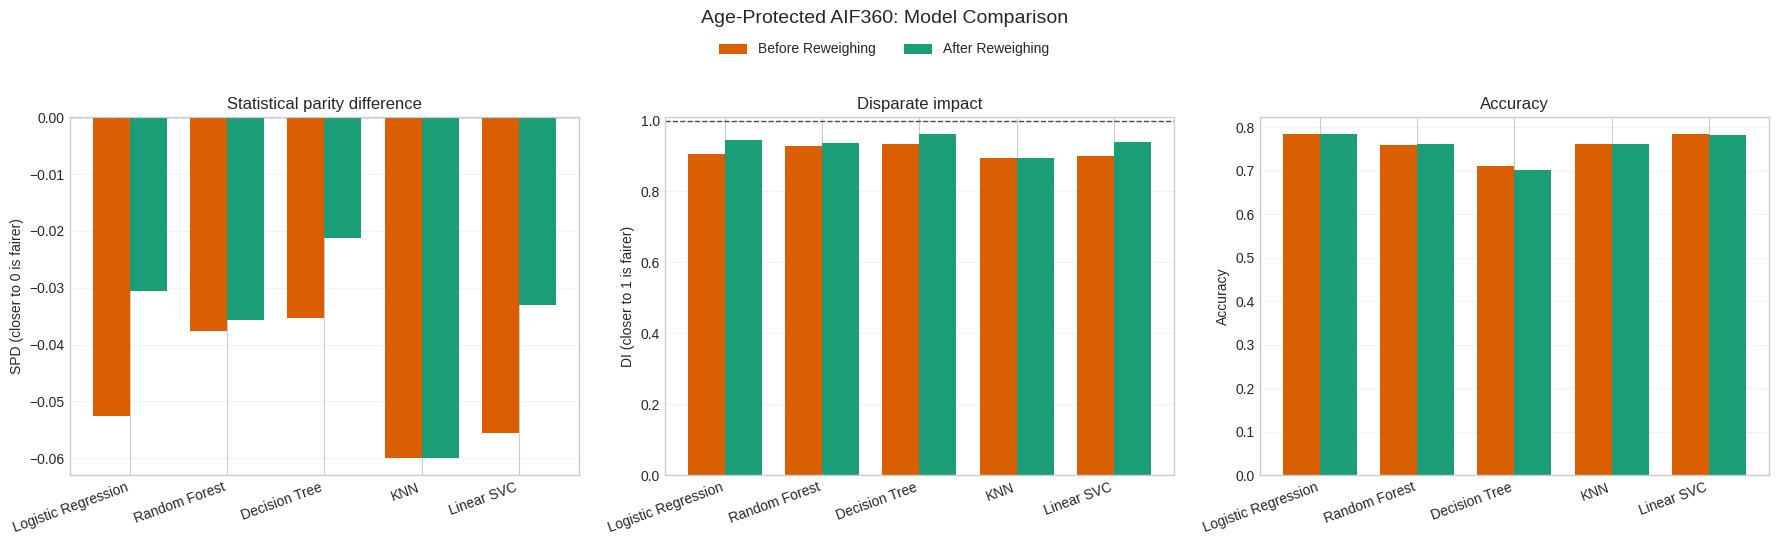

In [ ]:
plot_model_comparison(
    all_results["Age"]["before_df"],
    all_results["Age"]["after_df"],
    title="Age-Protected AIF360: Model Comparison",
    save_path=OUTPUT_DIR / "age_model_comparison_report_style.png",
)


### Mental Health Bias

This figure compares model fairness and accuracy before and after AIF360 reweighing when `MentalHealth` is the protected attribute. Following the original project logic, `No` is treated as the privileged group and all other values are treated as the unprivileged group.


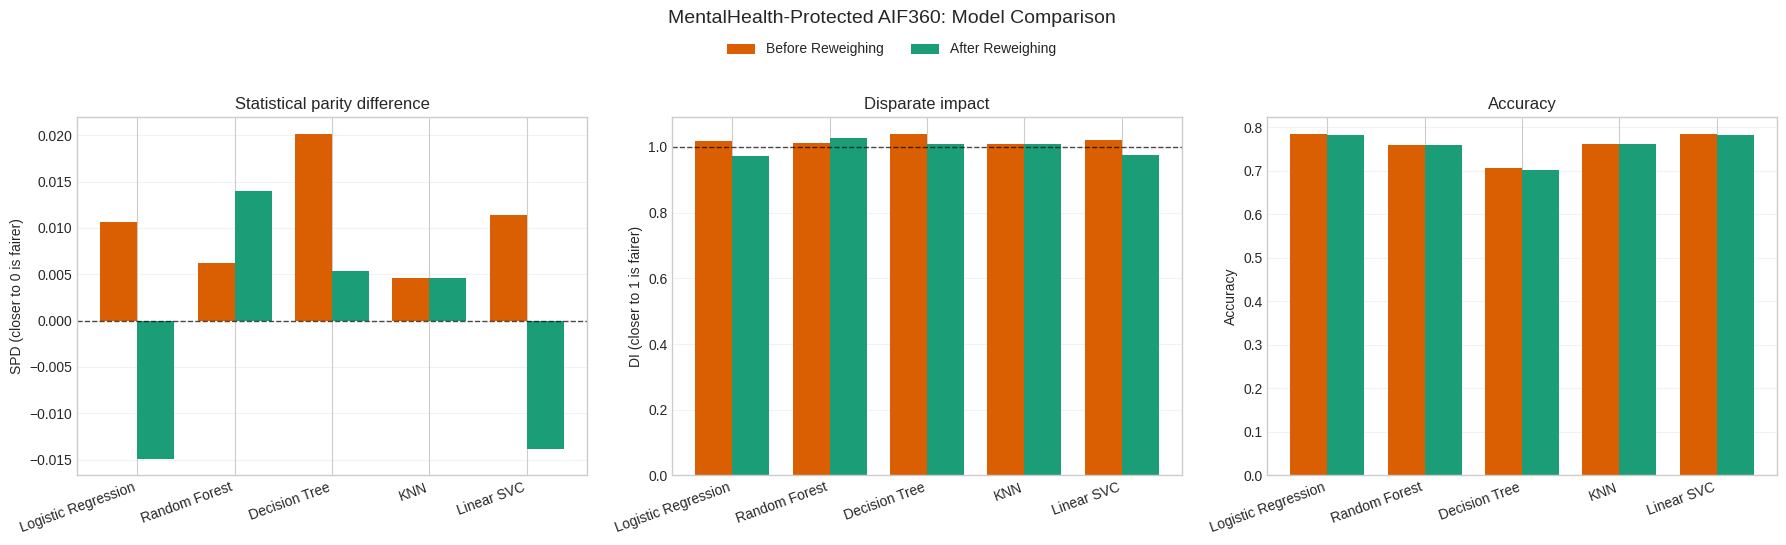

In [ ]:
plot_model_comparison(
    all_results["MentalHealth"]["before_df"],
    all_results["MentalHealth"]["after_df"],
    title="MentalHealth-Protected AIF360: Model Comparison",
    save_path=OUTPUT_DIR / "mental_health_model_comparison_report_style.png",
)


### Accessibility Bias

This figure compares model fairness and accuracy before and after AIF360 reweighing when `Accessibility` is the protected attribute. Here, `No` is treated as the privileged group and all other accessibility values are treated as the unprivileged group, matching the current analysis scripts.


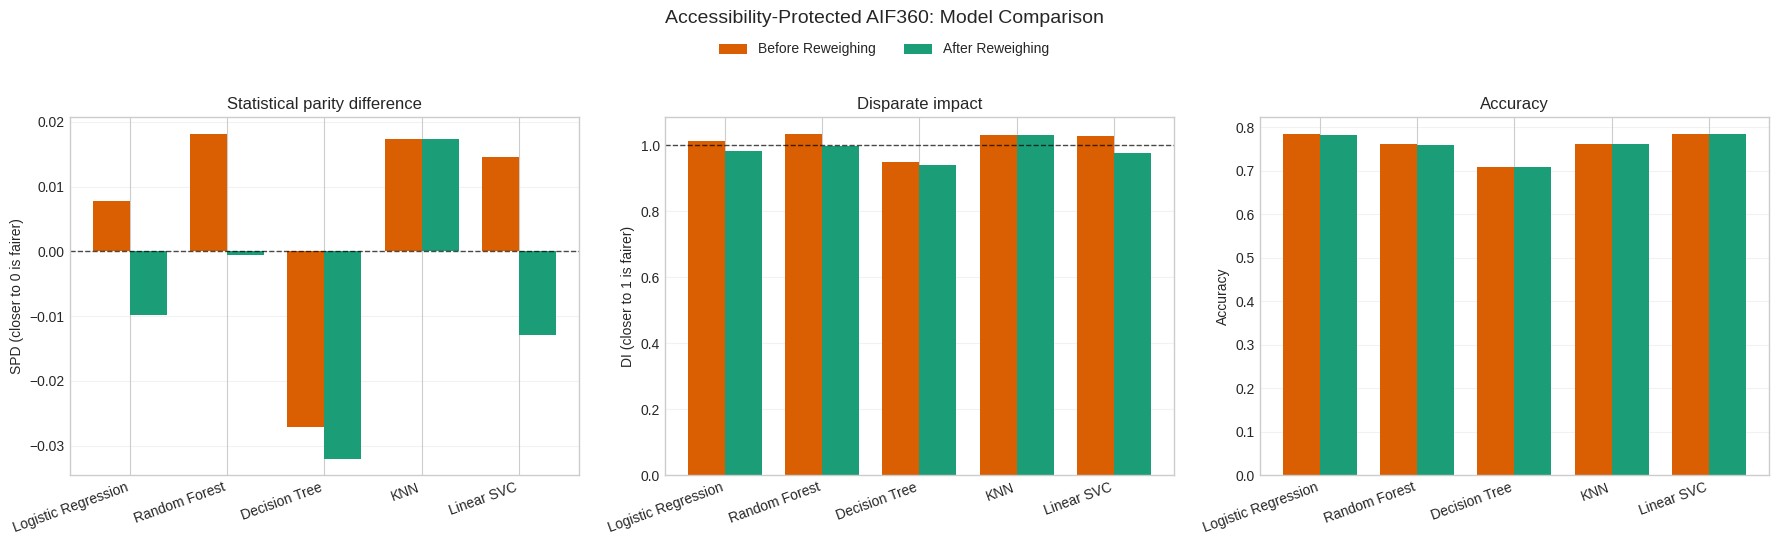

In [ ]:
plot_model_comparison(
    all_results["Accessibility"]["before_df"],
    all_results["Accessibility"]["after_df"],
    title="Accessibility-Protected AIF360: Model Comparison",
    save_path=OUTPUT_DIR / "accessibility_model_comparison_report_style.png",
)


### Country Bias

This figure compares model fairness and accuracy before and after AIF360 reweighing when `Country` is the protected attribute. The analysis uses a one-vs-rest setup in which `United States of America` is treated as the privileged country and all other countries are treated as the unprivileged group.


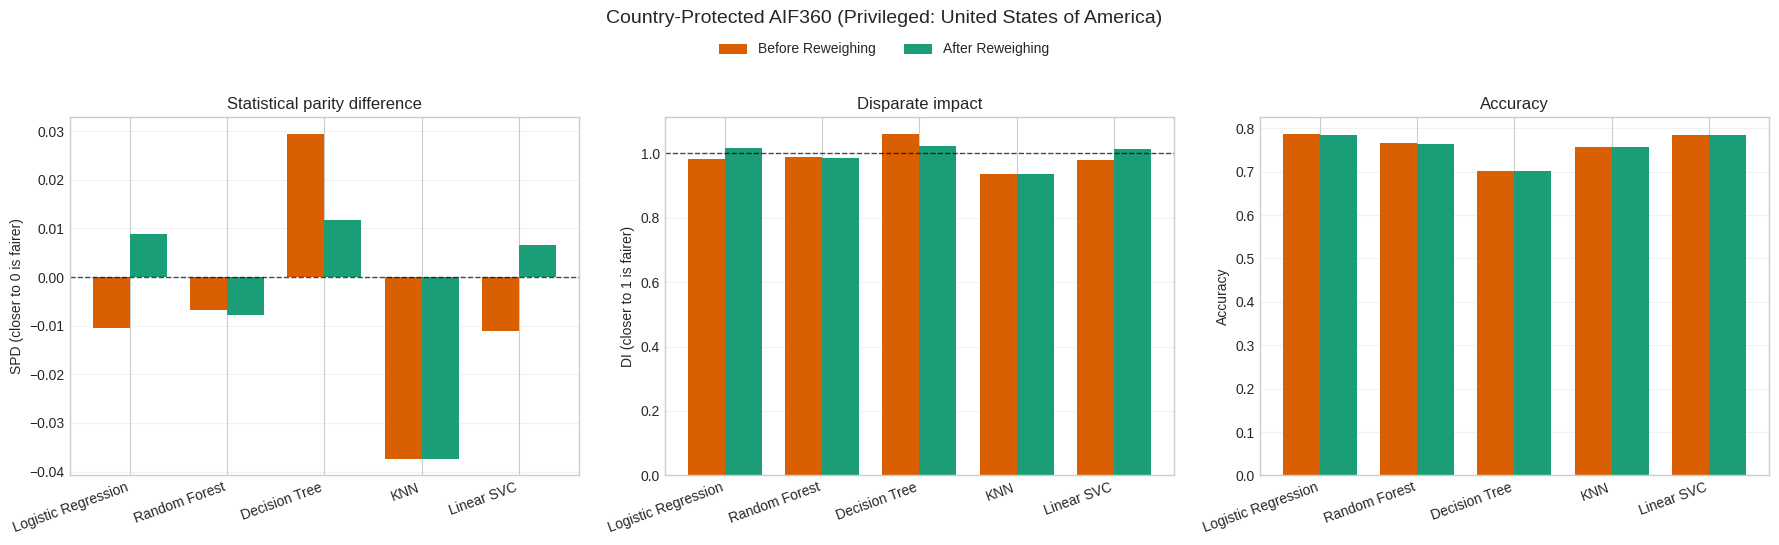

In [ ]:
plot_model_comparison(
    all_results["Country"]["before_df"],
    all_results["Country"]["after_df"],
    title=f"Country-Protected AIF360 (Privileged: {COUNTRY_PRIVILEGED})",
    save_path=OUTPUT_DIR / "country_model_comparison_report_style.png",
)


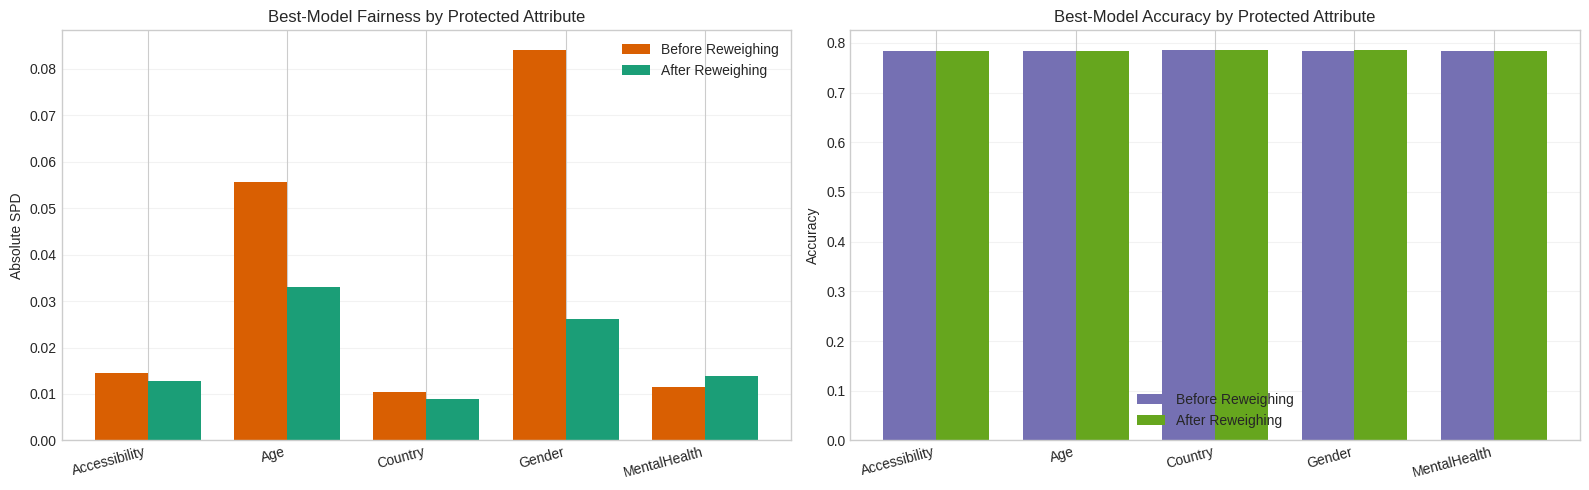


=== Gender ===


,Before,After
Statistical parity difference,-0.0744,0.0000
Disparate impact,0.8628,1.0000
Base rate privileged,0.5422,0.5374
Base rate unprivileged,0.4679,0.5374


,SPD_before,SPD_after,|SPD| improvement,DI_before,DI_after,Accuracy_before,Accuracy_after
Logistic Regression,-0.0785,-0.0249,0.0535,0.8558,0.9526,0.7838,0.7847
Random Forest,-0.0824,-0.0715,0.0109,0.8487,0.8703,0.7632,0.7650
Decision Tree,-0.0884,-0.0808,0.0076,0.8344,0.8482,0.7079,0.7061
KNN,-0.1063,-0.1063,0.0000,0.8096,0.8096,0.7593,0.7593
Linear SVC,-0.0841,-0.0262,0.0579,0.8442,0.9516,0.7837,0.7848



=== Age ===


,Before,After
Statistical parity difference,-0.0323,-0.0000
Disparate impact,0.9411,1.0000
Base rate privileged,0.5487,0.5374
Base rate unprivileged,0.5164,0.5374


...

,Before,After
Statistical parity difference,0.0345,-0.0000
Disparate impact,1.0643,1.0000
Base rate privileged,0.5364,0.5374
Base rate unprivileged,0.5709,0.5374


,SPD_before,SPD_after,|SPD| improvement,DI_before,DI_after,Accuracy_before,Accuracy_after
Logistic Regression,0.0078,-0.0099,-0.0020,1.0144,0.9819,0.7839,0.7837
Random Forest,0.0182,-0.0006,0.0176,1.0334,0.9990,0.7608,0.7596
Decision Tree,-0.0272,-0.0321,-0.0049,0.9486,0.9391,0.7083,0.7085
KNN,0.0173,0.0173,0.0000,1.0314,1.0314,0.7613,0.7613
Linear SVC,0.0145,-0.0129,0.0016,1.0271,0.9759,0.7838,0.7838



=== Country ===


,Before,After
Statistical parity difference,-0.0255,0.0000
Disparate impact,0.9542,1.0000
Base rate privileged,0.5578,0.5374
Base rate unprivileged,0.5323,0.5374


,SPD_before,SPD_after,|SPD| improvement,DI_before,DI_after,Accuracy_before,Accuracy_after
Logistic Regression,-0.0104,0.0088,0.0015,0.9810,1.0167,0.7859,0.7851
Random Forest,-0.0067,-0.0078,-0.0010,0.9876,0.9851,0.7657,0.7641
Decision Tree,0.0295,0.0117,0.0178,1.0585,1.0227,0.7010,0.7023
KNN,-0.0374,-0.0374,0.0000,0.9361,0.9361,0.7573,0.7573
Linear SVC,-0.0110,0.0066,0.0044,0.9795,1.0127,0.7838,0.7844


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

x = np.arange(len(multi_attribute_summary))
width = 0.38

axes[0].bar(
    x - width / 2,
    multi_attribute_summary["Best Model SPD Before"].abs(),
    width=width,
    label="Before Reweighing",
    color="#d95f02",
)
axes[0].bar(
    x + width / 2,
    multi_attribute_summary["Best Model SPD After"].abs(),
    width=width,
    label="After Reweighing",
    color="#1b9e77",
)
axes[0].set_xticks(x)
axes[0].set_xticklabels(multi_attribute_summary["Protected Attribute"], rotation=15, ha="right")
axes[0].set_ylabel("Absolute SPD")
axes[0].set_title("Best-Model Fairness by Protected Attribute")
axes[0].grid(axis="y", alpha=0.25)
axes[0].legend()

axes[1].bar(
    x - width / 2,
    multi_attribute_summary["Best Model Accuracy Before"],
    width=width,
    label="Before Reweighing",
    color="#7570b3",
)
axes[1].bar(
    x + width / 2,
    multi_attribute_summary["Best Model Accuracy After"],
    width=width,
    label="After Reweighing",
    color="#66a61e",
)
axes[1].set_xticks(x)
axes[1].set_xticklabels(multi_attribute_summary["Protected Attribute"], rotation=15, ha="right")
axes[1].set_ylabel("Accuracy")
axes[1].set_title("Best-Model Accuracy by Protected Attribute")
axes[1].grid(axis="y", alpha=0.25)
axes[1].legend()

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "cross_attribute_summary.png", dpi=180, bbox_inches="tight")
plt.show()

for protected_name, result in all_results.items():
    print(f"\n=== {protected_name} ===")
    display(pd.DataFrame({"Before": result["train_fairness_before"], "After": result["train_fairness_after"]}))
    display(result["comparison_df"].round(4))


The first figure compares fairness and accuracy at the attribute level, which makes it easier to see where reweighing helped most and where it came with more utility trade-off. The follow-up tables keep the analysis transparent by exposing each attribute’s train-split fairness shift and per-model before/after changes.


## 7. Save the Main Tables and Outputs


In [ ]:
export_paths = []

multi_attribute_summary_path = OUTPUT_DIR / "multi_attribute_summary.csv"
multi_attribute_summary.to_csv(multi_attribute_summary_path, index=False)
export_paths.append(multi_attribute_summary_path)

for protected_name, result in all_results.items():
    before_path = OUTPUT_DIR / f"{protected_name.lower()}_model_metrics_before.csv"
    after_path = OUTPUT_DIR / f"{protected_name.lower()}_model_metrics_after.csv"
    comparison_path = OUTPUT_DIR / f"{protected_name.lower()}_comparison.csv"
    prediction_path = OUTPUT_DIR / f"{protected_name.lower()}_best_model_predictions.csv"

    result["before_df"].to_csv(before_path)
    result["after_df"].to_csv(after_path)
    result["comparison_df"].to_csv(comparison_path)
    result["pred_df"].to_csv(prediction_path, index=False)

    export_paths.extend([before_path, after_path, comparison_path, prediction_path])

zip_path = OUTPUT_DIR / "hiring_bias_notebook_outputs.zip"
with zipfile.ZipFile(zip_path, "w", compression=zipfile.ZIP_DEFLATED) as zip_file:
    for file_path in OUTPUT_DIR.glob("*"):
        if file_path.is_file() and file_path.name != zip_path.name:
            zip_file.write(file_path, arcname=file_path.name)

print("Saved files:")
for file_path in sorted(OUTPUT_DIR.glob("*")):
    print(" -", file_path.name)

print("\nZIP archive:", zip_path)


Saved files:
 - accessibility_best_model_predictions.csv
 - accessibility_comparison.csv
 - accessibility_model_comparison_report_style.png
 - accessibility_model_metrics_after.csv
 - accessibility_model_metrics_before.csv
 - age_best_model_predictions.csv
 - age_comparison.csv
 - age_model_comparison_report_style.png
 - age_model_metrics_after.csv
 - age_model_metrics_before.csv
 - country_best_model_predictions.csv
 - country_comparison.csv
 - country_model_comparison_report_style.png
 - country_model_metrics_after.csv
 - country_model_metrics_before.csv
 - cross_attribute_summary.png
 - eda_gender_mental_health_heatmap.png
 - eda_hiring_bias_overview.png
 - gender_best_model_predictions.csv
 - gender_comparison.csv
 - gender_mental_health_prediction_heatmaps.png
 - gender_model_comparison.png
 - gender_model_comparison_report_style.png
 - gender_model_metrics_after.csv
 - gender_model_metrics_before.csv
 - gender_prediction_rates.png
 - gender_threshold_sweep.png
 - hiring_bias_note

This export cell turns the notebook into a deliverable rather than just an interactive analysis. It writes the key tables for every protected attribute, saves the generated figures, and bundles everything into one zip archive that can be downloaded from Colab if needed.


## 8. Summary and Conclusions


In [ ]:
largest_improvement = multi_attribute_summary.sort_values("|SPD| Improvement", ascending=False).iloc[0]
most_accurate_after = multi_attribute_summary.sort_values("Best Model Accuracy After", ascending=False).iloc[0]

print("=" * 90)
print("HIRING BIAS FAIRNESS SUMMARY")
print("=" * 90)
print(f"Rows analyzed: {len(clean_df):,}")
print(f"Protected attributes analyzed: {', '.join(multi_attribute_summary['Protected Attribute'])}")
print()
print(
    "Largest absolute SPD improvement after reweighing:",
    f"{largest_improvement['Protected Attribute']} "
    f"({largest_improvement['|SPD| Improvement']:.4f})",
)
print(
    "Highest post-mitigation accuracy among the best baseline models:",
    f"{most_accurate_after['Protected Attribute']} "
    f"({most_accurate_after['Best Model Accuracy After']:.4f})",
)
print()

for _, row in multi_attribute_summary.iterrows():
    print(
        f"{row['Protected Attribute']}: "
        f"best baseline model = {row['Best Baseline Model']}, "
        f"accuracy {row['Best Model Accuracy Before']:.4f} -> {row['Best Model Accuracy After']:.4f}, "
        f"SPD {row['Best Model SPD Before']:.4f} -> {row['Best Model SPD After']:.4f}"
    )


HIRING BIAS FAIRNESS SUMMARY
Rows analyzed: 73,462
Protected attributes analyzed: Accessibility, Age, Country, Gender, MentalHealth

Largest absolute SPD improvement after reweighing: Gender (0.0579)
Highest post-mitigation accuracy among the best baseline models: Country (0.7851)

Accessibility: best baseline model = Linear SVC, accuracy 0.7838 -> 0.7838, SPD 0.0145 -> -0.0129
Age: best baseline model = Linear SVC, accuracy 0.7838 -> 0.7830, SPD -0.0556 -> -0.0330
Country: best baseline model = Logistic Regression, accuracy 0.7859 -> 0.7851, SPD -0.0104 -> 0.0088
Gender: best baseline model = Linear SVC, accuracy 0.7837 -> 0.7848, SPD -0.0841 -> -0.0262
MentalHealth: best baseline model = Linear SVC, accuracy 0.7838 -> 0.7832, SPD 0.0114 -> -0.0139


This final cell converts the detailed outputs into a compact written conclusion. It highlights which protected attribute benefited most from reweighing, which setting retained the strongest predictive performance after mitigation, and how the best baseline model changed for each attribute.
